In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seting style
sns.set_style("whitegrid")
sns.set_palette(["#d73027", "#f46d43", "#4575b4"])

#Data file
df = pd.read_csv('CoffeeAndCode.csv')


In [2]:
# Remove NA values
df_clean = df.dropna(subset=['CodingHours', 'CoffeeTime', 'CodingWithoutCoffee'])

print(f"Original rows: {len(df)}")
print(f"Clean rows: {len(df_clean)}")

Original rows: 100
Clean rows: 100


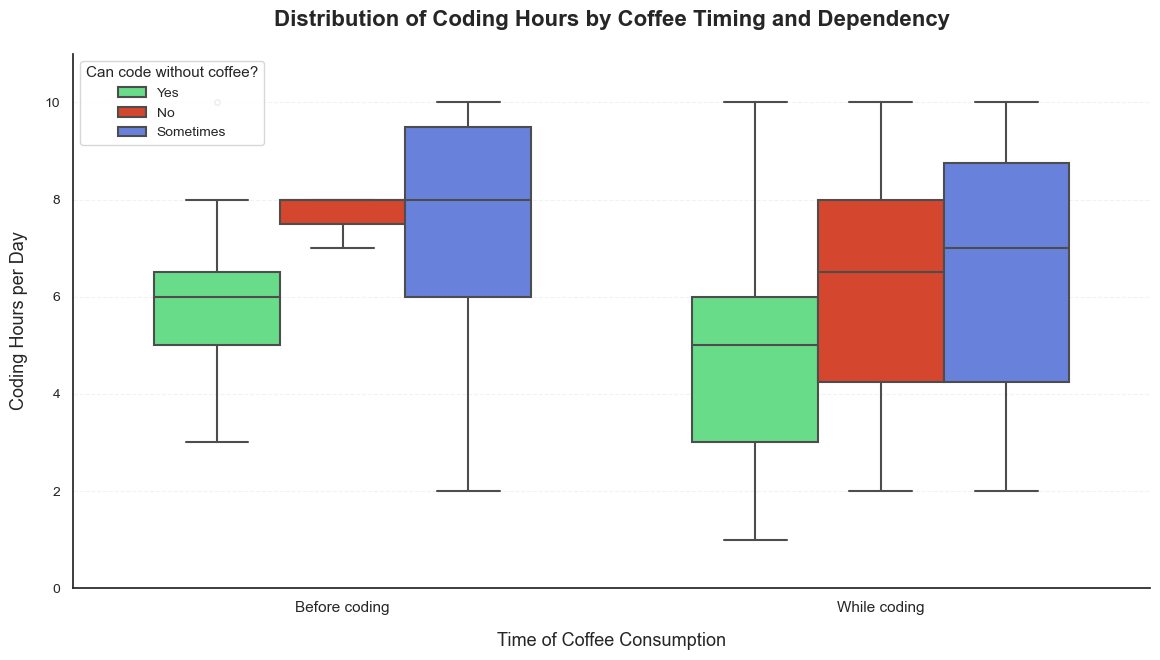

In [3]:
# Set professional style with minimal grid (Figure-Ground)
sns.set_style("white")
sns.set_context("notebook", font_scale=1.2)

dependency_colors = {
    'Yes': '#54F080',      
    'Sometimes': '#5477F0', 
    'No': '#F03311'         
}


# Filter data to coffee times with all three groups
coffee_times_to_keep = ['Before coding', 'While coding']
df_filtered = df[df['CoffeeTime'].isin(coffee_times_to_keep)]

# Create WIDER figure to reduce cramped feeling (Aesthetic)
plt.figure(figsize=(12, 7))

# Create box plot with adjustments
ax = sns.boxplot(
    data=df_filtered,
    x='CoffeeTime',
    y='CodingHours',
    hue='CodingWithoutCoffee',
    order=coffee_times_to_keep,
    palette=dependency_colors,
    width=0.7,              # Wider boxes for better visibility
    fliersize=4,            # Slightly larger outlier dots
    linewidth=1.5,          # Thicker box borders
    dodge=True              # Ensure proper side-by-side placement
)

# Customize title (Continuity - clear hierarchy)
plt.title('Distribution of Coding Hours by Coffee Timing and Dependency', 
          fontsize=16, fontweight='bold', pad=20)

# Axis labels with better spacing
plt.xlabel('Time of Coffee Consumption', fontsize=13, labelpad=12)
plt.ylabel('Coding Hours per Day', fontsize=13, labelpad=12)

# Set y-axis limits with some padding
plt.ylim(0, 11)

# Add light horizontal gridlines ONLY (Figure-Ground)
plt.grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.8)

# Remove top and right spines (Figure-Ground)
sns.despine(left=False, bottom=False, top=True, right=True)

# Move legend INSIDE the plot to reduce eye travel (Similarity + Proximity)
plt.legend(
    title='Can code without coffee?',
    title_fontsize=11,
    fontsize=10,
    loc='upper left',       # Inside the plot
    frameon=True,           # Light background
    facecolor='white',
    framealpha=0.9,
    edgecolor='lightgray'
)

# Increase x-axis label size and weight
plt.xticks(fontsize=11, fontweight='medium')
plt.yticks(fontsize=10)

# Adjust layout with more breathing room
plt.tight_layout(pad=1.5)

# Save high quality
plt.savefig('coffee_coding_boxplot_gestalt.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()